## **Gradiente Descendente (Machine Learning)**

Em Machine Learning, deseja-se encontrar os parâmetros que minimizam uma função de custo.

Considere o seguinte dataset:

$$
\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}
\quad \text{onde }
\mathbf{x}_i \in \mathbb{R}^{D}
\text{ e }
y_i \in \mathbb{R}
$$

Definimos a **função objetivo** como a média da perda sobre os dados:

$$
J(\mathbf{w}) = \frac{1}{N} \sum_{i=1}^{N} L_i(\mathbf{w})
\quad \text{onde} \quad
L_i(\mathbf{w}) = L\bigl(f(\mathbf{x}_i, \mathbf{w}),\, y_i\bigr)
$$

onde:
*   $f(\mathbf{x}_i, \mathbf{w})$ é o modelo parametrizado por $\mathbf{w}$
*   $L$ é a função perda


O objetivo consiste em:

$$
\min_{\mathbf{w}} J(\mathbf{w})
$$

Para isso, utilizamos o **gradiente descendente** definido como:

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \, \nabla J\bigl(\mathbf{w}^{(t)}\bigr)
$$

onde:

*   $\mathbf{w}^{(t)}$ é o vetor de parâmetros na iteração $t$
*   $\eta > 0$ é a taxa de aprendizado (*learning rate*)
*   $\nabla J(\mathbf{w})$ é o gradiente da função de custo

Como $J(\mathbf{w}) = \dfrac{1}{N}\displaystyle\sum_{i=1}^{N} L_i(\mathbf{w})$, pela linearidade do gradiente:

$$
\nabla J(\mathbf{w}) = \frac{1}{N} \sum_{i=1}^{N} \nabla L_i(\mathbf{w})
$$

Portanto, a regra de atualização pode ser escrita explicitamente como:

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \cdot \frac{1}{N} \sum_{i=1}^{N} \nabla L_i\!\left(\mathbf{w}^{(t)}\right)
$$


> GOODFELLOW, Ian; BENGIO, Yoshua; COURVILLE, Aaron. Deep Learning. Cambridge: MIT Press, 2016. Seção 5.9, p. 151.


> BISHOP, Christopher M. Pattern Recognition and Machine Learning. New York: Springer, 2006. Seção 4.3.2, p. 205.



## **Aplicação do Gradiente Descendente**

Vamos aplicar o método do GD para tarefa de **classificação binária** usando **Regressão Logística** no dataset [**Breast Cancer Wisconsin**](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html).

### **Processamentos dos Dados**

In [124]:
import numpy as np
import matplotlib.pyplot as plt

#### **Dataset**

In [125]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (569, 30)
Shape de y: (569,)


In [126]:
import pandas as pd

df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [127]:
print("Nomes das Classes:")
for name in data.target_names:
  print(name)

Nomes das Classes:
malignant
benign


In [128]:
df["target"].value_counts()

,count
target,
1,357
0,212


#### **Divisão do dataset nos conjuntos de treino e validação**

In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (455, 30)
Teste: (114, 30)


#### **Padronização dos dados (z-score)**

In [130]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### **Adicionando intercepto na matriz $\mathbf{X}$**

In [131]:
import numpy as np

def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack((ones, X))

X_train = add_bias(X_train)
X_test = add_bias(X_test)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (455, 31)
Teste: (114, 31)


In [132]:
n_features = X_train.shape[1]

w = np.zeros(n_features)

### **Implementação do GD e da Regressão Logística Binária**

A **Regressão Logística** usa a **função sigmóide** para modelar a probabilidade:

$$
\sigma(\mathbf{w}^\top \tilde{\mathbf{x}}_i) = \frac{1}{1 + e^{-\mathbf{w}^\top \tilde{\mathbf{x}}_i}}
$$

e minimiza a **entropia cruzada binária**:

$$
J(\mathbf{w}) = -\frac{1}{N} \sum_{i=1}^{N}
\Bigl[y_i \log \sigma(\mathbf{w}^\top \tilde{\mathbf{x}}_i)
+ (1 - y_i) \log\bigl(1 - \sigma(\mathbf{w}^\top \tilde{\mathbf{x}}_i)\bigr)\Bigr]
$$

Denotando $p_i = \sigma(\mathbf{w}^\top \tilde{\mathbf{x}}_i)$,
a derivada de $J$ em relação a $\mathbf{w}$ é:

$$
\nabla J(\mathbf{w})
= \frac{1}{N} \sum_{i=1}^{N} (p_i - y_i)\,\tilde{\mathbf{x}}_i
= \frac{1}{N}\, \mathbf{X}^\top (\mathbf{p} - \mathbf{y})
$$

onde $\mathbf{X}$ é a matriz de dados aumentada,
$\mathbf{p} = (p_1, \ldots, p_N)^\top$ e $\mathbf{y} = (y_1, \ldots, y_N)^\top$.

A **regra de atualização** do GD fica, portanto:

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \frac{\eta}{N}\, X^\top\bigl(\mathbf{p}^{(t)} - \mathbf{y}\bigr)
$$


#### **Funções auxiliares**

In [133]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_proba(X, w):
    z = X @ w
    return sigmoid(z)

def compute_loss(X, y, w):

    p = predict_proba(X, w)

    # evitar log(0)
    epsilon = 1e-15
    p = np.clip(p, epsilon, 1 - epsilon)

    J = -np.mean(
        y * np.log(p) + (1 - y) * np.log(1 - p)
    )

    return J

def compute_gradient(X, y, w):

    n = len(y)

    p = predict_proba(X, w)

    gradient = (X.T @ (p - y)) / n

    return gradient


#### **Regressão Logística Binária com GD**

In [134]:
def train_gd(X, y, w, eta=0.01, epochs=1000):

    losses = []

    for epoch in range(epochs):

        grad = compute_gradient(X, y, w)

        w = w - eta * grad

        loss = compute_loss(X, y, w)
        losses.append(loss)

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss:.4f}")

    return w, losses


### **Treinamento e Validação**

#### **Treinamento**

In [135]:
w, losses = train_gd(
    X_train,
    y_train,
    w,
    eta=0.01,
    epochs=1000
)

Epoch 0 | Loss: 0.6730
Epoch 100 | Loss: 0.2436
Epoch 200 | Loss: 0.1818
Epoch 300 | Loss: 0.1537
Epoch 400 | Loss: 0.1371
Epoch 500 | Loss: 0.1258
Epoch 600 | Loss: 0.1176
Epoch 700 | Loss: 0.1113
Epoch 800 | Loss: 0.1063
Epoch 900 | Loss: 0.1021


#### **Valor de $\mathbf{w}$ ótimo**

In [136]:
df_weights = pd.DataFrame({"feature": data.feature_names, "weight": w[1:]}).set_index("feature")

print(df_weights)

                           weight
feature                          
mean radius             -0.389912
mean texture            -0.356168
mean perimeter          -0.384951
mean area               -0.381141
mean smoothness         -0.176101
mean compactness        -0.147777
mean concavity          -0.264916
mean concave points     -0.376819
mean symmetry           -0.139789
mean fractal dimension   0.157052
radius error            -0.324937
texture error           -0.000123
perimeter error         -0.274750
area error              -0.313771
smoothness error         0.008766
compactness error        0.091957
concavity error          0.094303
concave points error    -0.081566
symmetry error           0.070590
fractal dimension error  0.188528
worst radius            -0.449217
worst texture           -0.414669
worst perimeter         -0.431931
worst area              -0.423195
worst smoothness        -0.298706
worst compactness       -0.216772
worst concavity         -0.277996
worst concave 

#### **Curva de Aprendizado**

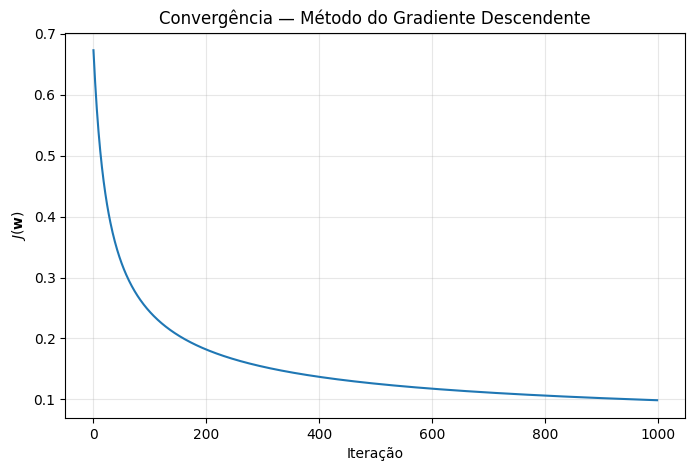

In [137]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Iteração")
plt.ylabel(r"$J(\mathbf{w})$")
plt.title(r"Convergência — Método do Gradiente Descendente")
plt.grid(True, alpha=0.3)
plt.show()

#### **Validação**

In [138]:
def predict(X, w, threshold=0.5):
    p = predict_proba(X, w)
    return (p >= threshold).astype(int)

In [139]:
y_pred = predict(X_test, w)

#### **Matriz de Confusão**

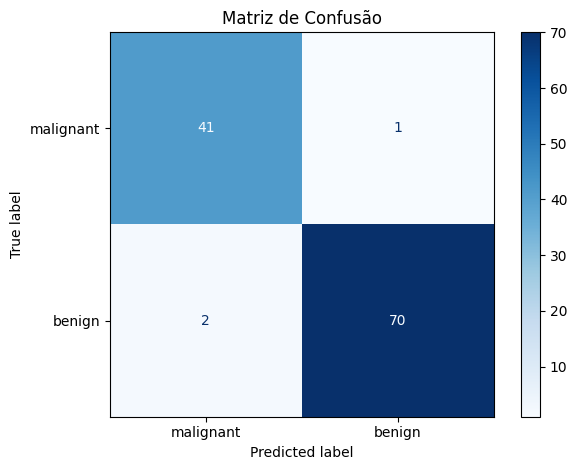

In [140]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

#### **Métricas**

In [141]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### **Visualização dos dados com PCA**

In [142]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train[:,1:])

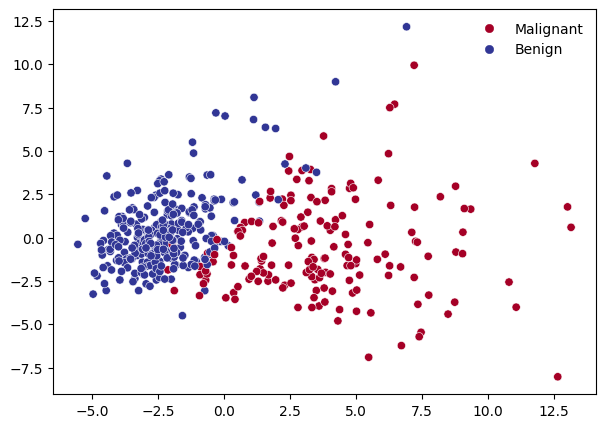

In [143]:
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=y_train, cmap="RdYlBu",
                     edgecolors="white", linewidths=0.4)

handles, _ = scatter.legend_elements()
ax.legend(handles, ["Malignant", "Benign"], frameon=False)
plt.show()